# Logging the logging over the last decades

The Bundesamt für Statistik (Federal Statistical Office of Germany) provides comprehensive data on logging activities in Germany over the last decades. This data includes information on the volume of timber harvested and the types of trees logged. Since the data is available from 1998 to 2025 multiple analyses can be performed.
For this work 5 research questions were formulated:
<mark>
1. How has the total volume of timber harvested in Germany changed over the last decades?
2. What are the reason behind the fluctuations in the volume of timber harvested in Germany?
3. What are the trends in logging activities for different types of woods in Germany?
4. What are the environmental impacts of logging activities in Germany?
5. What is the primary usage of the harvested timber in Germany?
</mark>

## Imports and Project Setup
In order to be able to rerun this notebook please execute the following steps:
```bash
python -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
```
This will create a virtual environment and install all necessary dependencies. After that you can run the notebook and execute the following code cells to import the necessary libraries and set up the project structure.
The following code cell is used to import the `DataLoader` class which is used to process the CSV-data provided in `data/` aswell as other dependencies used for visualization.

In [13]:
import data_loader
import tools
import numpy as np
from matplotlib import pyplot as plt
import importlib
importlib.reload(data_loader)

dl = data_loader.DataLoader()

## RQ1: How has the total volume of timber harvested in Germany changed over the last decades?
To answer this question, the `wood_production.csv` file will be used. It contains data from the Destatis website on the volume of wood production in Germany. It not only contains the total volume but also the volumes of different types of wood. For this research question however only the total volume will be used.

### Data processing
To process the data, the `DataLoader` class contains a method called `load_wood_production` which reads the CSV file and returns a DataFrame containing the relevant data. The following code cell demonstrates how to use this method. Also the data is filtered to only contain the time stamps from 1998 to 2025 and the actual value of the volume. This data will later be used for a visualization. 

In [14]:
overall_production = dl.load_overall_production("../data/wood_production.csv")
overall_production_sorted = overall_production[["time", "value"]].sort_values("time")

In addition to the concrete numerical values, a regression line is calculated to show the overall trend of the data.

In [15]:
slope, intercept = np.polyfit(overall_production_sorted["time"], overall_production_sorted["value"], 1)
x = np.linspace(overall_production_sorted["time"].min(), overall_production_sorted["time"].max(), 100)
y = slope * x + intercept

### Visualization
To visualize the data, the `matplotlib` library is used. The following code cell demonstrates how to create a line plot of the total volume of timber harvested over the years, along with the regression line to show the trend. The x-axis represents the years, while the y-axis represents the total volume of timber harvested in Germany.

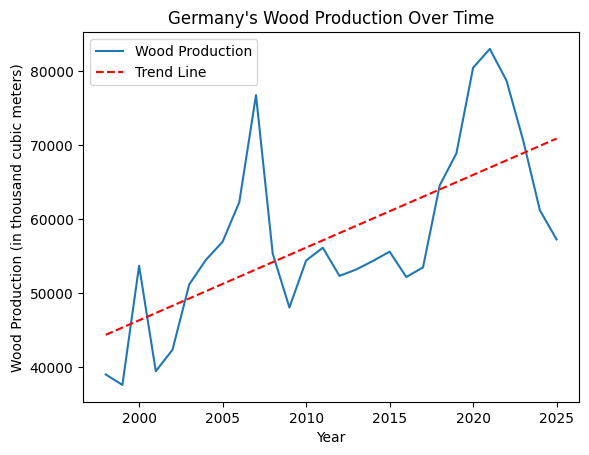

In [16]:
plt.plot(overall_production_sorted["time"].values, overall_production_sorted["value"].values, label="Wood Production")
plt.plot(x, y, color="red", linestyle="--", label=f"Trend Line")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Wood Production (in thousand cubic meters)")
plt.title("Germany's Wood Production Over Time")
plt.show()

### Analysis of the results and conclusion
As it can be seen in the plot, the volume of wood production in Germany is heavily increasing in trends of 1998 to 2025. This is especially observable in the regression line that shows a clear upward trend with a $\approx 1.5*x$ slope in a timespan of 27 years between 1998 and 2025. The actual trend line itself is not as linear and shows major fluctuations in the years 2000, 2004 to 2007 and 2017 to 2022. Since 2025 a downward trend can be observed. Finally, it can be concluded that the total volume of timber harvested in Germany has increased significantly over the last decades, with some fluctuations in between. What the reasons for these fluctuations are and how they can be explained will be analyzed in the next research questions.

## RQ2: What are the reason behind the fluctuations in the volume of timber harvested in Germany?
In order to fully understand the background of said fluctuations, more data is needed. For this purpose, literature research was conducted to find out what were the main driving factors behind the observed phenomenon. 

### Literature research
Many factors can influence the volume of timber harvested in a country. However, the most important ones are not the economic factors but rather the environmental ones. The spikes in overall volume observed in RQ1 can be almost perfectly explained by the occurrence of natural disasters such as storms, droughts and insect infestations. For the 2000 spike, the storm "Lothar" is beeing identified as the main driver. [[1]](https://www.holzkurier.com/rundholz/2023/07/holzeinschlag-deutschland-1998-2022.html)[[2]](https://de.wikipedia.org/wiki/Orkan_Lothar) For the 2007 spike, the storm "Kyrill" is identified as the main driver. [[1]](https://www.holzkurier.com/rundholz/2023/07/holzeinschlag-deutschland-1998-2022.html)[[3]](https://de.wikipedia.org/wiki/Orkan_Kyrill) Finally, the spike between 2017 and 2022 can be explained by a combination of droughts and insect infestations. [[1]](https://www.holzkurier.com/rundholz/2023/07/holzeinschlag-deutschland-1998-2022.html)[[4]](https://www.waldwissen.net/de/waldwirtschaft/schadensmanagement/insekten/artikelsammlung-zu-borkenkaefer)

### Visualization
To visualize the results of the literature research, the same plot but without the regression line from RQ1 is used with the addition of annotations that indicate the exact dates of the natural disasters.


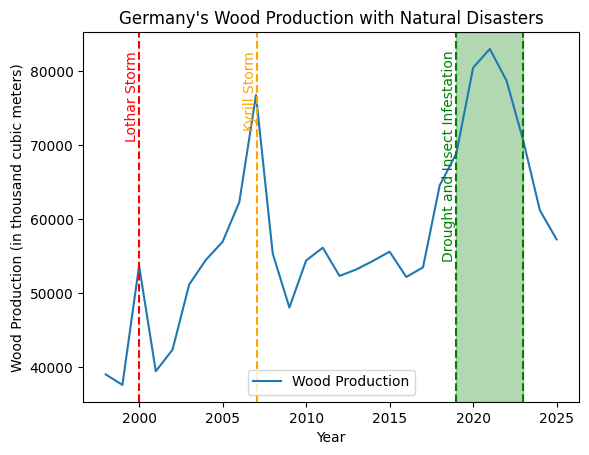

In [17]:
plt.plot(overall_production_sorted["time"].values, overall_production_sorted["value"].values, label="Wood Production")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Wood Production (in thousand cubic meters)")
plt.title("Germany's Wood Production with Natural Disasters")

ax = plt.gca()
ax.axvline(tools.date_to_numerical_year("25-12-1999"), color='red', linestyle='--')
ax.text(tools.date_to_numerical_year("25-12-1999"), 0.95, "Lothar Storm", transform=ax.get_xaxis_transform(),
        rotation=90, va='top', ha='right', color='red')

bx = plt.gca()
bx.axvline(tools.date_to_numerical_year("18-01-2007"), color='orange', linestyle='--')
bx.text(tools.date_to_numerical_year("18-01-2007"), 0.95, "Kyrill Storm", transform=bx.get_xaxis_transform(),
        rotation=90, va='top', ha='right', color='orange')

cx = plt.gca()
cx.axvspan(tools.date_to_numerical_year("01-01-2019"), tools.date_to_numerical_year("31-12-2022"), color='green', alpha=0.3)
cx.axvline(tools.date_to_numerical_year("01-01-2019"), color='green', linestyle='--')
cx.axvline(tools.date_to_numerical_year("31-12-2022"), color='green', linestyle='--')
cx.text(tools.date_to_numerical_year("01-01-2019"), 0.95, "Drought and Insect Infestation", transform=cx.get_xaxis_transform(),
        rotation=90, va='top', ha='right', color='green')

plt.show()


### Analysis of the results and conclusion
As it can be seen in the plot, "Germany's Wood Production with Natural Disasters", the spikes in wood production can be almost perfectly explained by the occurrence of natural disasters. The storm "Lothar" in 1999 caused a significant increase in wood production due to the large number of trees that were damaged and needed to be harvested. Similarly, the storm "Kyrill" in 2007 also led to a spike in wood production for the same reasons. The period from 2019 to 2022, which is marked as "Drought and Insect Infestation", also shows a significant increase in wood production, likely due to the increased need for harvesting trees that were affected by drought and insect infestations. Overall, it can be concluded that natural disasters have a significant impact on the volume of timber harvested in Germany, leading to fluctuations in wood production over the years and even make up a substantial part of the overall wood production. Wether that additional wood was utilized will be analyzed in RQ5.

## RQ3: What are the trends in logging activities for different types of woods in Germany?
To answer this question, the `wood_production.csv` file will be used again but this time not the total volume but the volumes of the different types of wood will be analyzed. 

### Data processing
To process the data, the `DataLoader` class contains a method called `load_wood_production_by_type` which reads the same CSV file but this time returns a bigger DataFrame containing the values for the different types of wood indexed by the time stamps. This are then assigned to different variables for the different types of wood.

In [18]:
beech_and_other_hardood, jaw_and_larch, oak_and_red_oak, spruce_fir_douglas_fir_and_other_softwood = dl.load_wood_production_by_type("../data/wood_production.csv")

### Visualization
In order to visualize the different trends for the different types of wood, a multi-line plot is beeing created.

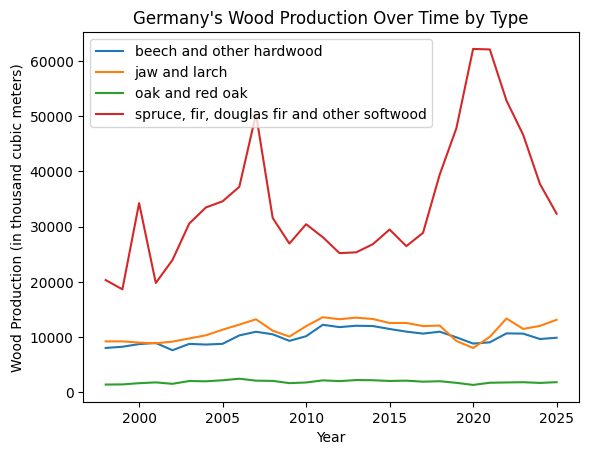

In [19]:
plt.plot(beech_and_other_hardood["time"].values, beech_and_other_hardood["value"].values, label="beech and other hardwood")
plt.plot(jaw_and_larch["time"].values, jaw_and_larch["value"].values, label="jaw and larch")
plt.plot(oak_and_red_oak["time"].values, oak_and_red_oak["value"].values, label="oak and red oak")
plt.plot(spruce_fir_douglas_fir_and_other_softwood["time"].values, spruce_fir_douglas_fir_and_other_softwood["value"].values, label="spruce, fir, douglas fir and other softwood")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Wood Production (in thousand cubic meters)")
plt.title("Germany's Wood Production Over Time by Type")
plt.show()

### Analysis of the results and conclusion
As it can be seen in the plot, "Germany's Wood Production by Type", the absolute majority is made up by softwood. This is not surprising at all since softwoods tend to grow very fast and thus are more commonly used for day-to-day purposes such as construction, furniture and paper production. Other woods such as hardwood, jaw or oak have a noticeable low fluctuation since they are not as commonly used and thus not as heavily harvested. Only a small portion of objects such as certain furniture or flooring are made out of these woods. Since the softwood trend is almost identical to the total volume trend, for which we earlier identified the natural disasters as the main driver for fluctuations, it can be assumed that most woods that are present in germany are in fact softwoods and thus the natural disasters mainly affected said softwoods.

## RQ4: What are the environmental impacts of logging activities in Germany?
This research question can be tackled from multiple angles. Since the problem of environmental impacts of any process is a very broad one, focusing on one specific aspect is necessary. For this project, the focus will be on the the numerical value of the carbon emission caused by logging as well as the reproduction time of the logged trees and the concluding binding of the carbon emissions.

### Approximate carbon emissions from logging activities
To estimate the carbon emissions from logging activities in Germany, we can use the following assumptions:
- One $m^3$ of wood weighs approximately 500 kg.
- The carbon content of wood is about 50% of its dry weight.
- Therefore, one $m^3$ of wood contains approximately 250 kg of carbon.
- The carbon atom molecular weight of 12 u and the oxygen atom molecular weight of 16 u, the molecular weight of $CO_2$ is 44 u. This means that 1 kg of carbon corresponds to 44/12 kg of $CO_2$, which is approximately 3.67 kg of $CO_2$.

Based on these assumptions, we can calculate the approximate binding of carbon dioxide per $m^3$ of wood as follows:
$C \text{ binding per } m^3 = 250 \text{ kg of carbon} \times 3.67 \text{ kg of } CO_2 \text{ per kg of carbon} = 917.5 \text{ kg of } CO_2 \text{ per } m^3$

This means that approximately 917.5 kg of $CO_2$ is bound in one $m^3$ of wood.

In order to calculate the total carbon emission and binding from a numerical value of $m^3$ of logged wood, we now implement the following function:

In [20]:
def wood_cubic_meters_to_co2_equivalent(cubic_meters):
    # This is a very rough estimate and can vary greatly depending on the type of wood and its moisture content
    # On average, 1 cubic meter of wood can sequester about 0.9175 tons of CO2
    # This value is in tons.
    return cubic_meters * 0.9175

This function can now be applied to estimate the carbon sequestration from logging activities. 

In [21]:
overall_production = dl.load_overall_production("../data/wood_production.csv")
overall_production_sorted = overall_production[["time", "value"]].sort_values("time")
overall_production_sorted["co2_equivalent"] = overall_production_sorted["value"].apply(wood_cubic_meters_to_co2_equivalent)

To put this value into perspective, the total volume of wood growth in Germany can be used. For that the value of the Fachagentur Nachwachsende Rohstoffe (Agency for Renewable Resources) can be used which states that the total growth of wood in Germany is approximately 101.5 million $m^3$ per year. [[5]](https://holz.fnr.de/rohstoff-holz/holzvorrat)
We can now plot this value over the years to see how the carbon sequestration from logging activities has changed over time as well as the total wood growth in Germany. 

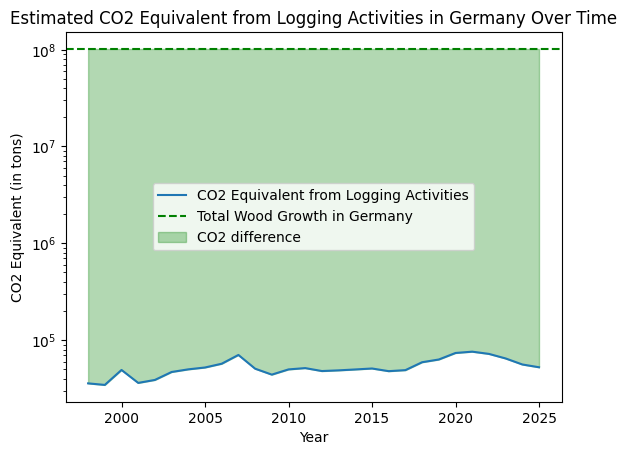

In [22]:
plt.plot(overall_production_sorted["time"].values, overall_production_sorted["co2_equivalent"].values, label="CO2 Equivalent from Logging Activities")
plt.axhline(101500000, color='green', linestyle='--', label="Total Wood Growth in Germany")
plt.fill_between(overall_production_sorted["time"].values, overall_production_sorted["co2_equivalent"].values, 101500000, alpha=0.3, color='green', label="CO2 difference")
plt.yscale('log')
plt.legend()
plt.xlabel("Year")
plt.ylabel("CO2 Equivalent (in tons)")
plt.title("Estimated CO2 Equivalent from Logging Activities in Germany Over Time")
plt.show()

### Analysis of the results and conclusion
The difference between the carbon binding from the total growth and the harvesting is in the realm of several magnitudes. This means that the overall growth has a huge net positive over the harvesting. This does not necessarily mean that the logging activities do not have a significant impact on the environment. However, it does show that the overall growth of wood in Germany is much higher than the amount of wood that is being harvested, which is a positive sign for the sustainability of logging activities in Germany. Also this calculation does not take other factors such as transportation emissions, soil disturbance and biodiversity loss into account.

## RQ5: What is the primary usage of the harvested timber in Germany?
Here the data from the previous dataset is not sufficient since it only allows to analyze volumes of wood production. In order to still be able to answer this question further data was obtainer by the Bundesministerium für Ernährung
und Landwirtschaft (Federal Ministry of Food and Agriculture). This state organization provides a decadal report on the usage of woods produced in Germany. Sadly this data is only beeing provided as a PDF file and thus needs to be extracted manually. For the following analysis, the wood type spruce will be used.

### Data processing
The data from the PDF file was extracted manually and stored in a CSV file called `spruce_usage.csv`. Also another `DataLoader` method called `load_spruce_usage` was implemented to read the CSV file and return multiple DataFrames containing the relevant data.

In [23]:
sawlogs, industry, energy, unused = dl.load_spruce_usage("../data/spruce_usage.csv")

### Visualization
To visualize the data, a multi-line plot is created to show the different usage types of spruce over the years.

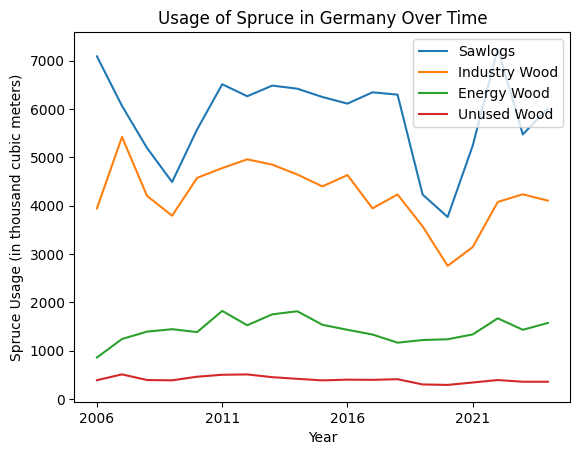

In [24]:
plt.plot(sawlogs["time"].values, sawlogs["value"].values, label="Sawlogs")
plt.plot(industry["time"].values, industry["value"].values, label="Industry Wood")
plt.plot(energy["time"].values, energy["value"].values, label="Energy Wood")
plt.plot(unused["time"].values, unused["value"].values, label="Unused Wood")
plt.legend()
plt.xlabel("Year")
plt.xticks(np.arange(sawlogs["time"].min(), sawlogs["time"].max() + 1, 5))
plt.ylabel("Spruce Usage (in thousand cubic meters)")
plt.title("Usage of Spruce in Germany Over Time")
plt.show()

### Analysis of the results and conclusion
The graph shows that the majority of produced spruce is being utilized as sawlogs, which are used for construction and furniture production. The second largest usage type is industry wood, which is used for paper production and other industrial purposes. Energy wood, which is used for bioenergy production, has a smaller share. The portion of unused wood from the produced spruce is very small which is a positive sign for the sustainability. What makes this graph interesting is the fact that energy wood has almost no increase which means that the increase in wood production is not being used for energy production but rather for construction and paper production. This again shows that sustainability is a very important discussion point when it comes to logging activities in Germany.

## Conclusion
In this project, we analyzed the logging activities in Germany over the last decades. We found that the total volume of timber harvested in Germany has increased significantly over the last decades, with some fluctuations in between. The spikes in wood production can be almost perfectly explained by the occurrence of natural disasters. The estimated carbon binding from logging activities shows that the overall growth of wood in Germany is much higher than the amount of wood that is being harvested, which is a positive sign for the sustainability of logging activities in Germany. Finally, the majority of produced spruce is being utilized as sawlogs, which are used for construction and furniture production, while energy wood has almost no increase which means that the increase in wood production is not being used for energy production but rather for construction and paper production. This again shows that sustainability is a very important discussion point when it comes to the topic wood in Germany.